# Tutorial 01: Prefix Sampling & The GNN Training Signal

In Stage 1 of the training pipeline, we need to teach a GNN to "see the future" of a search tree.

This tutorial explores **Prefix Sampling**: how we take a deep "Oracle" tree and chop it into a training pair: 
1. **Input:** A shallow partial tree (Only raw heuristic values known).
2. **Target:** The deep values from the full search.

In [1]:
import os
import sys
from pathlib import Path
import chess

# Setup environment and PATH
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"
LMCOS_DIR = Path(os.getcwd()).parent
if str(LMCOS_DIR) not in sys.path:
    sys.path.insert(0, str(LMCOS_DIR))

from helper_prefix import visualize_unified_tree
from tree import SearchTree, ExpansionChild
from schema import TREE_ENCODER_FEATURE_NAMES

## Step 1: Create a Deep Oracle Tree (The Ground Truth)

We'll build an Oracle tree with **10 nodes** and sample a **6-node prefix**.

**Mechanistic Truth:** The GNN expects 5 features per node: `value`, `wdl_win`, `wdl_draw`, `wdl_loss`, and `wdl_var`. We include these in our simulation to match the production schema.

In [2]:
def build_oracle_and_partial():
    t = SearchTree()
    # Standard production feature set
    static = {f: 0.33 for f in TREE_ENCODER_FEATURE_NAMES}
    static["value"] = 0.5
    static["wdl_var"] = 0.1
    
    # 0: Root
    t.create_root(chess.STARTING_FEN, static)
    
    # Path 1 & 2: e4 (1) and d4 (2)
    b1 = chess.Board(); b1.push_uci("e2e4")
    b2 = chess.Board(); b2.push_uci("d2d4")
    p_ids = t.add_children(0, [
        ExpansionChild("e2e4", b1.fen(), static), # Node 1
        ExpansionChild("d2d4", b2.fen(), static)  # Node 2
    ])
    
    # Path 1 extensions: e5 (3), c5 (4)
    b3 = b1.copy(); b3.push_uci("e7e5")
    b4 = b1.copy(); b4.push_uci("c7c5")
    c_ids_path1 = t.add_children(p_ids[0], [
        ExpansionChild("e7e5", b3.fen(), static), # Node 3
        ExpansionChild("c7c5", b4.fen(), static)  # Node 4
    ])
    
    # Path 2 extensions: d5 (5)
    b5 = b2.copy(); b5.push_uci("d7d5")
    c_ids_path2 = t.add_children(p_ids[1], [
        ExpansionChild("d7d5", b5.fen(), static)  # Node 5
    ])
    
    # --- ORACLE FUTURE (Not in Prefix) ---
    win_discovery = {"value": 0.9, "wdl_win": 0.9, "wdl_draw": 0.1, "wdl_loss": 0.0, "wdl_var": 0.01}
    b6 = b3.copy(); b6.push_uci("g1f3")
    b7 = b6.copy(); b7.push_uci("b8c6")
    f_ids_1 = t.add_children(3, [ExpansionChild("Nf3", b6.fen(), win_discovery)]) # 6
    t.add_children(f_ids_1[0], [ExpansionChild("Nc6", b7.fen(), win_discovery)]) # 7
    
    b8 = b5.copy(); b8.push_uci("g1f3")
    b9 = b5.copy(); b9.push_uci("c2c4")
    t.add_children(5, [
        ExpansionChild("Nf3", b8.fen(), static), # 8
        ExpansionChild("c4", b9.fen(), static)       # 9
    ])

    inputs = {i: (0.33, 0.33, 0.33) for i in range(6)}
    targets = { 0: (0.5, 0.3, 0.2), 1: (0.8, 0.1, 0.1), 2: (0.33, 0.33, 0.33), 3: (0.9, 0.1, 0.0), 4: (0.33, 0.33, 0.33), 5: (0.33, 0.33, 0.33), 6: (0.9, 0.1, 0.0), 7: (0.9, 0.1, 0.0), 8: (0.33, 0.33, 0.33), 9: (0.33, 0.33, 0.33) }
    prefix_ids = set(range(6))
    return t, prefix_ids, inputs, targets

oracle, prefix_ids, inputs, targets = build_oracle_and_partial()
print(f"Oracle nodes: {oracle.num_nodes()}")
print(f"Prefix nodes (GNN sees these): {len(prefix_ids)}")

Oracle nodes: 10
Prefix nodes (GNN sees these): 6


## Step 2: The Unified Search Context

Notice the **Board State** inside each node! 

- By looking at the board in **Node 3**, the GNN should ideally recognize an "Open Game" structure. 
- Since deep search (Gray nodes) found a win from there, the **TARGET** value (0.9) is much higher than the initial static **INPUT** (0.33).
- The GNN's job is to bridge that gap by pattern matching the boards and the tree structure.

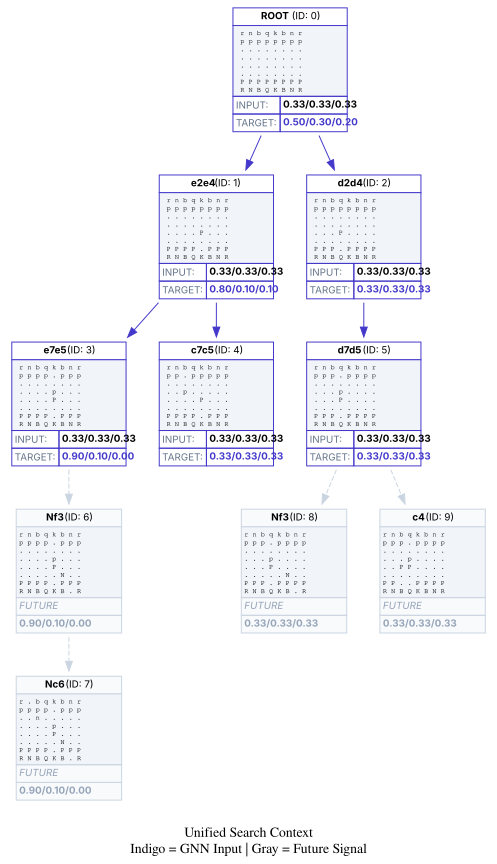

In [3]:
display(visualize_unified_tree(oracle, prefix_ids, inputs, targets))

### Mechanistic Mapping

To see where this logic lives in the codebase:
1. **`cts_pretrain.py [generate_partial_tree_from_provider]`**: This function coordinates the search and the "chopping" of the tree into a prefix.
2. **`cts_pretrain.py [consolidate_generated_tree]`**: This is where the "Future Signal" is calculated by taking deep search results and propagating them back up to create the learning targets.